In [1]:
'''## Student Productivity & Behavior Dataset (20K)
https://www.kaggle.com/datasets/algozee/student-productivity-and-behavior-dataset-20k

Источник: Kaggle – Student Productivity & Behavior Dataset (20K)  
Цель: понять, как учебные привычки, сон и цифровые дистракции связаны с уровнем продуктивности студентов.'''

#!pip install pandas numpy matplotlib seaborn plotly scikit-learn scipy --upgrade



'## Student Productivity & Behavior Dataset (20K)\nhttps://www.kaggle.com/datasets/algozee/student-productivity-and-behavior-dataset-20k\n\nИсточник: Kaggle – Student Productivity & Behavior Dataset (20K)  \nЦель: понять, как учебные привычки, сон и цифровые дистракции связаны с уровнем продуктивности студентов.'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

df = pd.read_csv("student_productivity_distraction_dataset_20000.csv")
print(f"✅ Загружено: {df.shape}")
display(df.head(2))


✅ Загружено: (20000, 18)


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99


In [3]:
print("📋 Info:")
df.info()
print("\n📈 Числа:")
display(df.describe())
print("\n🔤 Категории:")
display(df.describe(include=['object','string']))
print(f"\n❌ Пропуски: {df.isnull().sum().sum()}, Дубли: {df.duplicated().sum()}")


📋 Info:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  str    
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  focus

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000



🔤 Категории:


,gender
count,20000
unique,3
top,Female
freq,9640



❌ Пропуски: 0, Дубли: 0


In [4]:
missing = df.isnull().sum()[df.isnull().sum()>0]
if len(missing)>0:
    plt.figure(figsize=(10,4))
    sns.heatmap(df.isnull(), yticklabels=False, cmap='viridis')
    plt.title("Пропуски")
    plt.show()
    
    # Заполнение
    num_na = df.select_dtypes(np.number).columns[df.select_dtypes(np.number).isnull().any()]
    if len(num_na)>0:
        col = num_na[0]
        df[f"{col}_median"] = df[col].fillna(df[col].median())
        print(f"✅ Заполнены {col}")


In [5]:
num_cols = df.select_dtypes(np.number).columns
if len(num_cols)>0:
    stats = pd.DataFrame({
        'mean': df[num_cols].mean(),
        'skew': df[num_cols].skew(),
        'kurt': df[num_cols].kurtosis()
    }).round(3)
    display(stats.head(8))


,mean,skew,kurt
student_id,10000.500,0.000,-1.200
age,23.007,0.000,-1.213
study_hours_per_day,5.255,0.007,-1.198
sleep_hours,6.518,-0.006,-1.208
phone_usage_hours,6.250,0.006,-1.200
social_media_hours,4.004,-0.006,-1.188
youtube_hours,2.990,0.004,-1.189
gaming_hours,2.988,0.013,-1.205


In [6]:
# OHE
cat_cols = df.select_dtypes(['object','string']).columns
if cat_cols.any():
    df_ohe = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print(f"OHE: {df.shape}→{df_ohe.shape}")

# Новые фичи
phone_cols = [c for c in df.columns if any(w in c.lower() for w in ['phone','screen','social'])]
df['total_digital'] = df[phone_cols].sum(axis=1, skipna=True) if phone_cols else 0

sleep_cols = [c for c in df.columns if 'sleep' in c.lower()]
study_cols = [c for c in df.columns if 'study' in c.lower()]
if sleep_cols and study_cols:
    df['sleep_ratio'] = df[sleep_cols[0]] / df[study_cols[0]]

print("✅ Фичи:", ['total_digital', 'sleep_ratio'])
display(df[['total_digital', 'sleep_ratio']].head())


OHE: (20000, 18)→(20000, 19)
✅ Фичи: ['total_digital', 'sleep_ratio']


,total_digital,sleep_ratio
0,6.11,0.834483
1,6.99,1.071661
2,8.46,0.654618
3,14.01,1.435737
4,4.61,0.809648


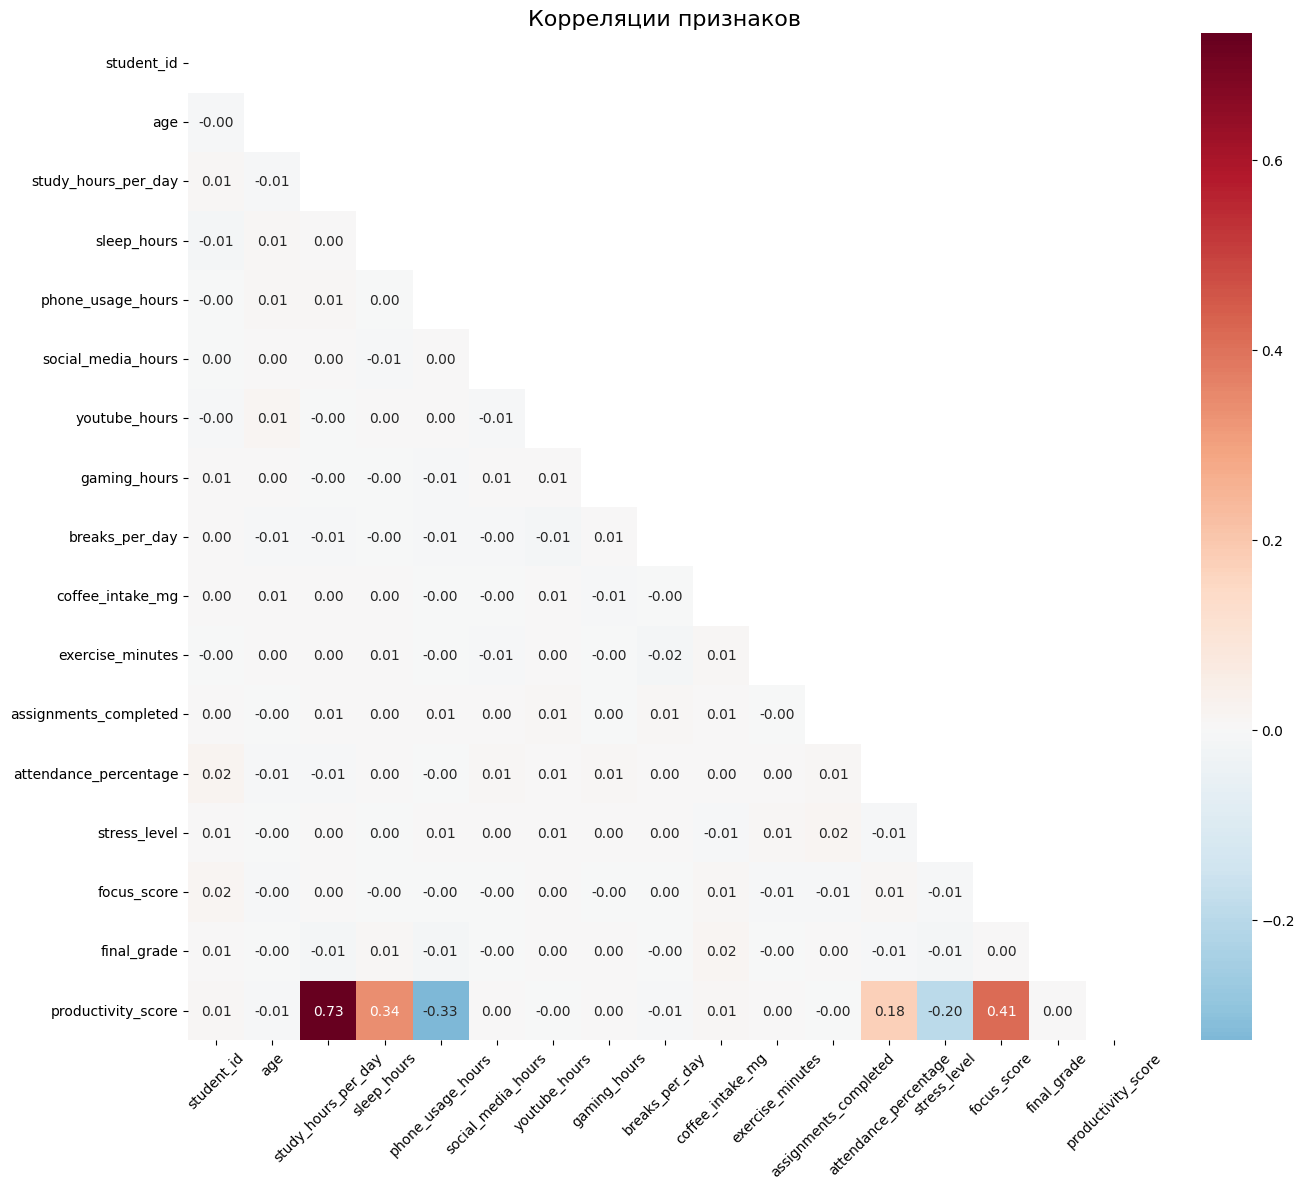

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("student_productivity_distraction_dataset_20000.csv")
num_cols = df.select_dtypes(np.number).columns
corr = df[num_cols].corr()

plt.figure(figsize=(14,12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Корреляции признаков', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


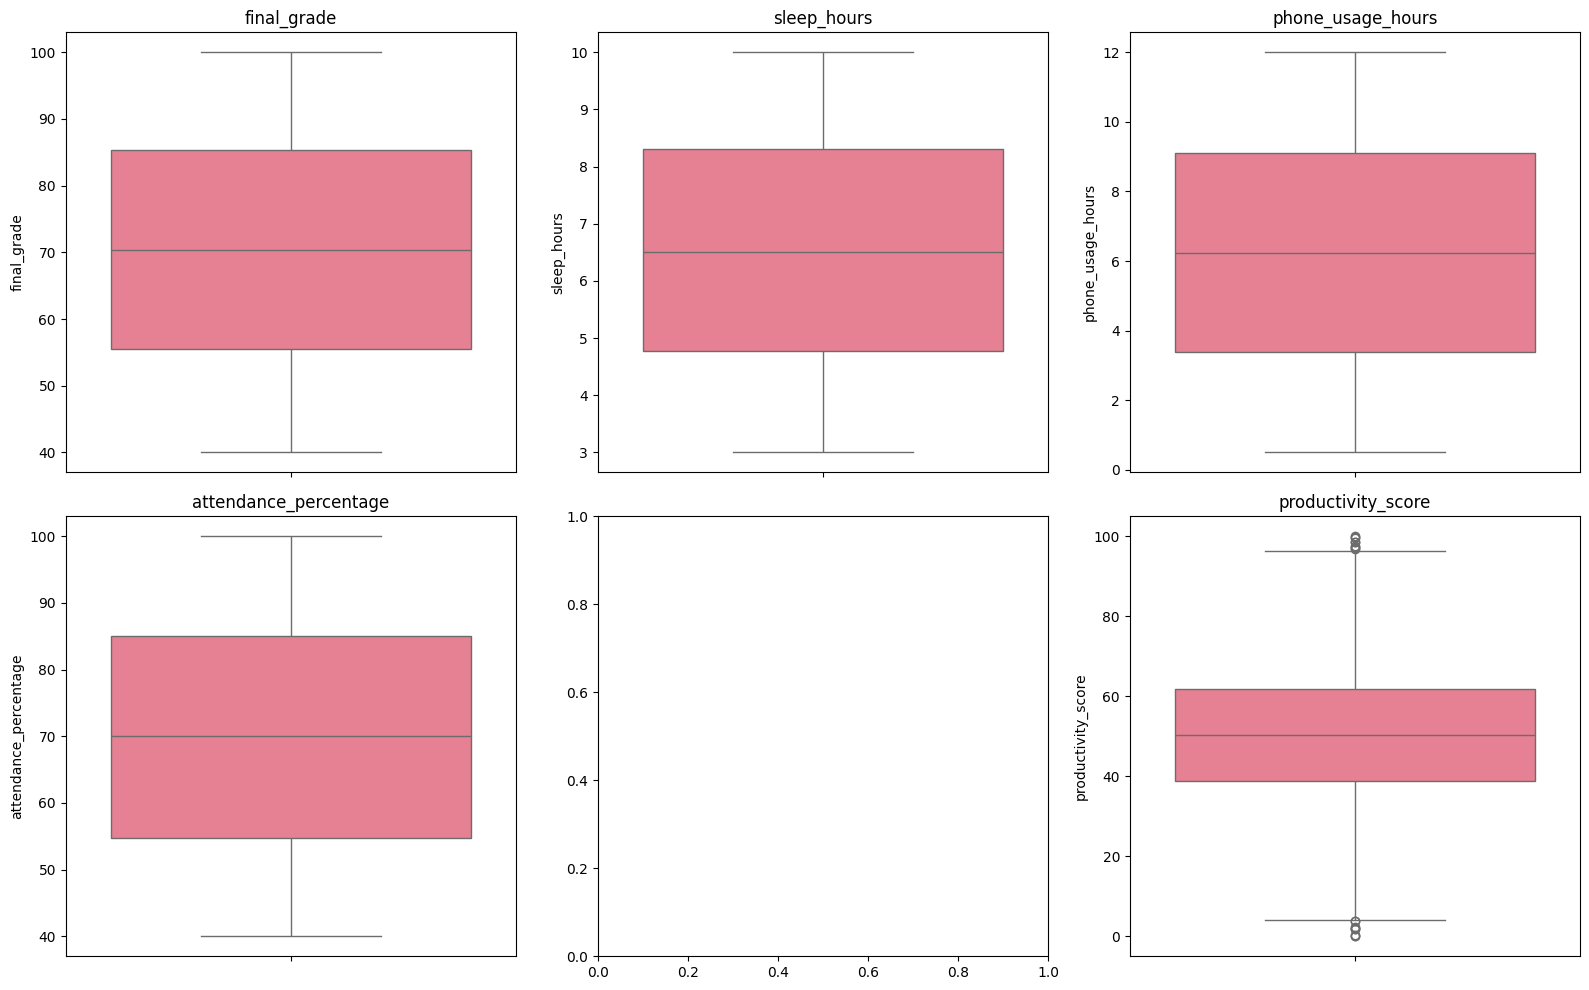

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2,3,figsize=(16,10))
cols = ['final_grade','sleep_hours','phone_usage_hours','attendance_percentage','studyhoursperday','productivity_score']
for i,col in enumerate(cols):
    if col in df:
        sns.boxplot(y=df[col], ax=axes[i//3,i%3])
        axes[i//3,i%3].set_title(col)
plt.tight_layout()
plt.show()



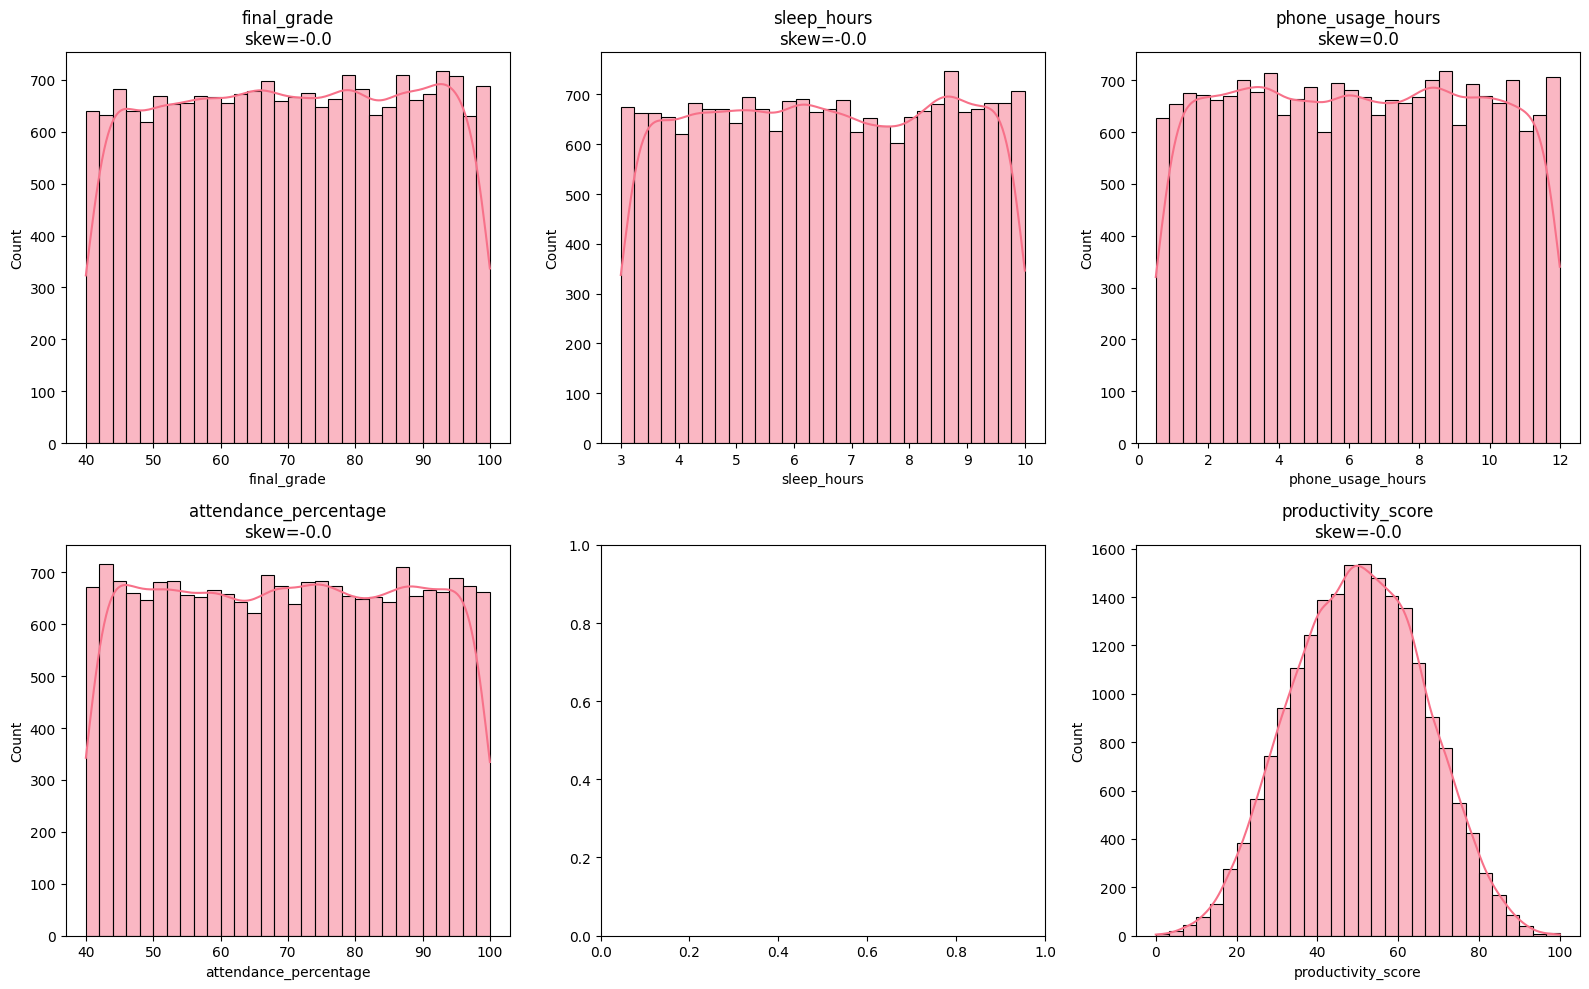

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2,3,figsize=(16,10))
cols = ['final_grade','sleep_hours','phone_usage_hours','attendance_percentage','studyhoursperday','productivity_score']
for i,col in enumerate(cols):
    if col in df:
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i//3,i%3])
        axes[i//3,i%3].set_title(f'{col}\nskew={df[col].skew():.1f}')
plt.tight_layout()
plt.show()


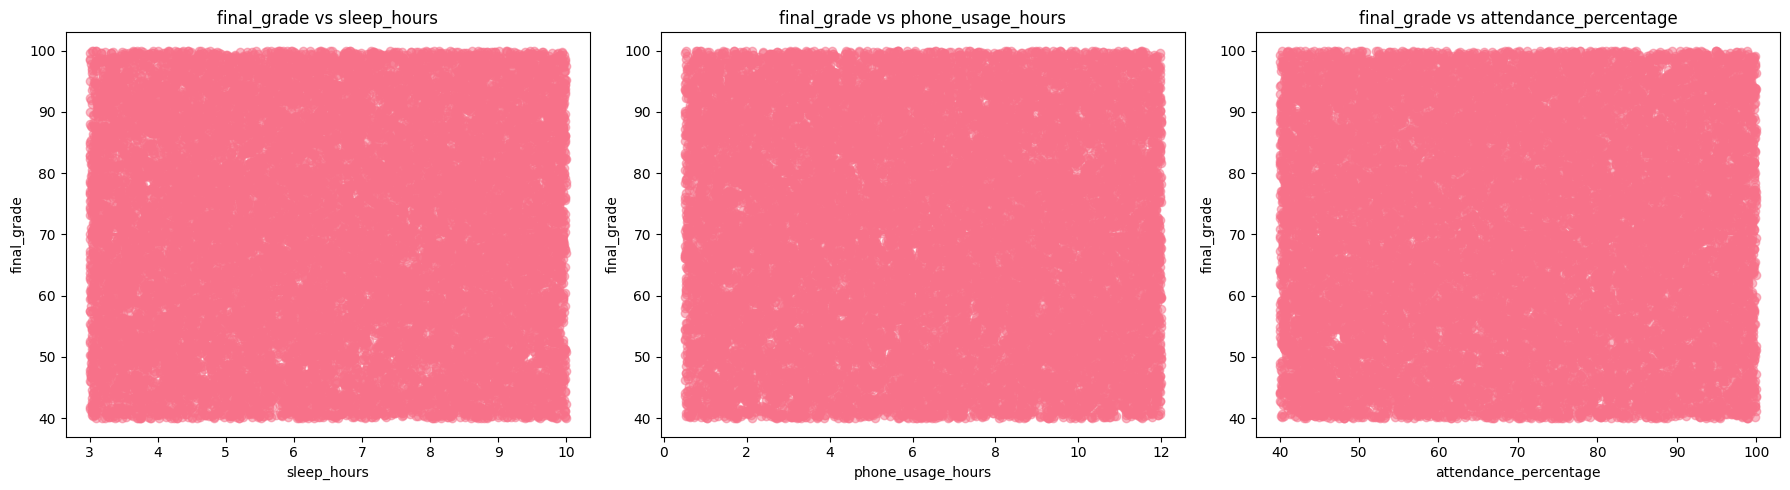

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,3,figsize=(18,5))
pairs = [('sleep_hours','final_grade'), ('phone_usage_hours','final_grade'), ('attendance_percentage','final_grade')]
for i,(x,y) in enumerate(pairs):
    if x in df and y in df:
        sns.regplot(data=df, x=x, y=y, ax=axes[i], scatter_kws={'alpha':0.5})
        axes[i].set_title(f'{y} vs {x}')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

target = 'final_grade'
corrs = df.corr(numeric_only=True)[target].sort_values(ascending=False)
plt.figure(figsize=(12,8))
corrs.drop(target).head(10).plot(kind='barh', color=sns.color_palette('husl',10))
plt.title('ТОП-10 факторов final_grade', fontsize=16)
plt.xlabel('Корреляция ρ')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("🏆 TOP+3:", corrs.head(3).round(3))
